# 03 - Baseline Model

## Objective

The purpose of this notebook is to train and evaluate a baseline machine learning model for predicting California home sale prices.

In this notebook, we will:

- Load the cleaned training and testing datasets created during preprocessing.
- Separate the predictor variables from the target variable.
- Train a baseline Linear Regression model.
- Generate predictions on the testing data.
- Evaluate model performance using standard regression metrics.

The results from this notebook will serve as a benchmark for comparing more advanced machine learning models later in the project.

In [1]:
# ============================================
# Import required libraries
# ============================================

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    root_mean_squared_error,
    r2_score,
)

# Display all columns when inspecting DataFrames
pd.set_option("display.max_columns", None)

## Load the Cleaned Datasets

The preprocessing notebook produced separate training and testing datasets that are ready for machine learning.

In this section, we will:

- Load the cleaned training dataset.
- Load the cleaned testing dataset.
- Verify that both datasets were imported successfully.
- Confirm their dimensions before building the baseline model.

In [2]:
# ============================================
# Load the cleaned training and testing datasets
# ============================================

data_path = Path("../data")

train = pd.read_csv(data_path / "train_cleaned.csv")
test = pd.read_csv(data_path / "test_cleaned.csv")

print("Datasets loaded successfully!\n")

print(f"Training rows: {train.shape[0]:,}")
print(f"Training columns: {train.shape[1]}")

print()

print(f"Testing rows: {test.shape[0]:,}")
print(f"Testing columns: {test.shape[1]}")

Datasets loaded successfully!

Training rows: 327,668
Training columns: 308

Testing rows: 12,024
Testing columns: 308


## Inspect the Datasets

Before training a model, it's a good idea to quickly inspect the datasets to make sure they loaded correctly.

We'll display the first few rows of both the training and testing datasets.

In [3]:
# Display the first few rows of the training dataset
train.head()

,ClosePrice,Latitude,Longitude,LivingArea,ParkingTotal,LotSizeAcres,YearBuilt,StreetNumberNumeric,BathroomsTotalInteger,BedroomsTotal,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,ViewYN_True,PoolPrivateYN_True,AttachedGarageYN_True,FireplaceYN_True,NewConstructionYN_True,"Levels_MultiSplit,One",Levels_One,"Levels_One,MultiSplit","Levels_One,ThreeOrMore","Levels_One,Two","Levels_One,Two,MultiSplit","Levels_One,Two,ThreeOrMore","Levels_One,Two,ThreeOrMore,MultiSplit",Levels_ThreeOrMore,"Levels_ThreeOrMore,MultiSplit","Levels_ThreeOrMore,One",Levels_Two,"Levels_Two,MultiSplit","Levels_Two,MultiSplit,One","Levels_Two,One","Levels_Two,ThreeOrMore","Levels_Two,ThreeOrMore,MultiSplit",CountyOrParish_Alpine,CountyOrParish_Amador,CountyOrParish_Butte,CountyOrParish_Calaveras,CountyOrParish_Clark,CountyOrParish_Colusa,CountyOrParish_Contra Costa,CountyOrParish_Del Norte,CountyOrParish_El Dorado,CountyOrParish_Foreign Country,CountyOrParish_Fresno,CountyOrParish_Glenn,CountyOrParish_Humboldt,CountyOrParish_Imperial,CountyOrParish_Inyo,CountyOrParish_Kern,CountyOrParish_Kings,CountyOrParish_Lake,CountyOrParish_Lassen,CountyOrParish_Los Angeles,CountyOrParish_Madera,CountyOrParish_Marin,CountyOrParish_Mariposa,CountyOrParish_Mendocino,CountyOrParish_Merced,CountyOrParish_Modoc,CountyOrParish_Mono,CountyOrParish_Monterey,CountyOrParish_Napa,CountyOrParish_Nevada,CountyOrParish_Orange,CountyOrParish_Other,CountyOrParish_Other County,CountyOrParish_Other State,CountyOrParish_Placer,CountyOrParish_Plumas,CountyOrParish_Riverside,CountyOrParish_SAN DIEGO,CountyOrParish_Sacramento,CountyOrParish_San Benito,CountyOrParish_San Bernardino,CountyOrParish_San Diego,CountyOrParish_San Francisco,CountyOrParish_San Joaquin,CountyOrParish_San Luis Obispo,CountyOrParish_San Mateo,CountyOrParish_Santa Barbara,CountyOrParish_Santa Clara,CountyOrParish_Santa Cruz,CountyOrParish_Shasta,CountyOrParish_Sierra,CountyOrParish_Siskiyou,CountyOrParish_Solano,CountyOrParish_Sonoma,CountyOrParish_Stanislaus,CountyOrParish_Sutter,CountyOrParish_Tehama,CountyOrParish_Trinity,CountyOrParish_Tulare,CountyOrParish_Tuolumne,CountyOrParish_Ventura,CountyOrParish_Yolo,CountyOrParish_Yuba,StateOrProvince_AZ,StateOrProvince_BC,StateOrProvince_CA,StateOrProvince_CO,StateOrProvince_FL,StateOrProvince_GA,StateOrProvince_ME,StateOrProvince_MO,StateOrProvince_NV,StateOrProvince_NY,StateOrProvince_OS,StateOrProvince_TN,StateOrProvince_TX,BuyerOfficeAOR_BayEast,BuyerOfficeAOR_BeverlyHillsGreaterLA,BuyerOfficeAOR_BeverlyHillsGreaterLa,BuyerOfficeAOR_Burbank,BuyerOfficeAOR_CLAW,BuyerOfficeAOR_CaliforniaDesert,BuyerOfficeAOR_CitrusValley,BuyerOfficeAOR_Claw,BuyerOfficeAOR_CoastalMendocino,BuyerOfficeAOR_Conejo,BuyerOfficeAOR_ContraCosta,BuyerOfficeAOR_Delta,BuyerOfficeAOR_Downey,BuyerOfficeAOR_EastValley,BuyerOfficeAOR_Fresno,BuyerOfficeAOR_Glendale,BuyerOfficeAOR_HemetSanJacinto,BuyerOfficeAOR_HighDesert,BuyerOfficeAOR_Inglewood,BuyerOfficeAOR_InlandValleys,BuyerOfficeAOR_JoshuaTreeGateway,BuyerOfficeAOR_Laguna,BuyerOfficeAOR_LakeCounty,BuyerOfficeAOR_MLSListings,BuyerOfficeAOR_MRMLS,BuyerOfficeAOR_Madera,BuyerOfficeAOR_Malibu,BuyerOfficeAOR_MariposaCounty,BuyerOfficeAOR_MercedCounty,BuyerOfficeAOR_Mlslistings,BuyerOfficeAOR_MontebelloDistrict,BuyerOfficeAOR_Mrmls,BuyerOfficeAOR_Newport,BuyerOfficeAOR_NorthSanDiegoCounty,BuyerOfficeAOR_NorthSanLuisObispo,BuyerOfficeAOR_Oakland,BuyerOfficeAOR_OrangeCounty,BuyerOfficeAOR_Oroville,BuyerOfficeAOR_OutOfAreaBoard,BuyerOfficeAOR_OutofAreaBoard,BuyerOfficeAOR_PacificSouthwest,BuyerOfficeAOR_PacificWest,BuyerOfficeAOR_PalmSprings,BuyerOfficeAOR_PalosVerdesPeninsula,BuyerOfficeAOR_Paradise,BuyerOfficeAOR_PasadenaFoothills,BuyerOfficeAOR_PismoCoast,BuyerOfficeAOR_RanchoSoutheast,BuyerOfficeAOR_ReciprocalBoard,BuyerOfficeAOR_RimOTheWorld,BuyerOfficeAOR_SacramentoAssociationOfRealtorsInc,BuyerOfficeAOR_SacramentoAssociationofRealtorsInc,BuyerOfficeAOR_SanDiego,BuyerOfficeAOR_SanFrancisco,BuyerOfficeAOR_SanLuis

In [4]:
# Display the first few rows of the testing dataset
test.head()

,ClosePrice,Latitude,Longitude,LivingArea,ParkingTotal,LotSizeAcres,YearBuilt,StreetNumberNumeric,BathroomsTotalInteger,BedroomsTotal,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,ViewYN_True,PoolPrivateYN_True,AttachedGarageYN_True,FireplaceYN_True,NewConstructionYN_True,"Levels_MultiSplit,One",Levels_One,"Levels_One,MultiSplit","Levels_One,ThreeOrMore","Levels_One,Two","Levels_One,Two,MultiSplit","Levels_One,Two,ThreeOrMore","Levels_One,Two,ThreeOrMore,MultiSplit",Levels_ThreeOrMore,"Levels_ThreeOrMore,MultiSplit","Levels_ThreeOrMore,One",Levels_Two,"Levels_Two,MultiSplit","Levels_Two,MultiSplit,One","Levels_Two,One","Levels_Two,ThreeOrMore","Levels_Two,ThreeOrMore,MultiSplit",CountyOrParish_Alpine,CountyOrParish_Amador,CountyOrParish_Butte,CountyOrParish_Calaveras,CountyOrParish_Clark,CountyOrParish_Colusa,CountyOrParish_Contra Costa,CountyOrParish_Del Norte,CountyOrParish_El Dorado,CountyOrParish_Foreign Country,CountyOrParish_Fresno,CountyOrParish_Glenn,CountyOrParish_Humboldt,CountyOrParish_Imperial,CountyOrParish_Inyo,CountyOrParish_Kern,CountyOrParish_Kings,CountyOrParish_Lake,CountyOrParish_Lassen,CountyOrParish_Los Angeles,CountyOrParish_Madera,CountyOrParish_Marin,CountyOrParish_Mariposa,CountyOrParish_Mendocino,CountyOrParish_Merced,CountyOrParish_Modoc,CountyOrParish_Mono,CountyOrParish_Monterey,CountyOrParish_Napa,CountyOrParish_Nevada,CountyOrParish_Orange,CountyOrParish_Other,CountyOrParish_Other County,CountyOrParish_Other State,CountyOrParish_Placer,CountyOrParish_Plumas,CountyOrParish_Riverside,CountyOrParish_SAN DIEGO,CountyOrParish_Sacramento,CountyOrParish_San Benito,CountyOrParish_San Bernardino,CountyOrParish_San Diego,CountyOrParish_San Francisco,CountyOrParish_San Joaquin,CountyOrParish_San Luis Obispo,CountyOrParish_San Mateo,CountyOrParish_Santa Barbara,CountyOrParish_Santa Clara,CountyOrParish_Santa Cruz,CountyOrParish_Shasta,CountyOrParish_Sierra,CountyOrParish_Siskiyou,CountyOrParish_Solano,CountyOrParish_Sonoma,CountyOrParish_Stanislaus,CountyOrParish_Sutter,CountyOrParish_Tehama,CountyOrParish_Trinity,CountyOrParish_Tulare,CountyOrParish_Tuolumne,CountyOrParish_Ventura,CountyOrParish_Yolo,CountyOrParish_Yuba,StateOrProvince_AZ,StateOrProvince_BC,StateOrProvince_CA,StateOrProvince_CO,StateOrProvince_FL,StateOrProvince_GA,StateOrProvince_ME,StateOrProvince_MO,StateOrProvince_NV,StateOrProvince_NY,StateOrProvince_OS,StateOrProvince_TN,StateOrProvince_TX,BuyerOfficeAOR_BayEast,BuyerOfficeAOR_BeverlyHillsGreaterLA,BuyerOfficeAOR_BeverlyHillsGreaterLa,BuyerOfficeAOR_Burbank,BuyerOfficeAOR_CLAW,BuyerOfficeAOR_CaliforniaDesert,BuyerOfficeAOR_CitrusValley,BuyerOfficeAOR_Claw,BuyerOfficeAOR_CoastalMendocino,BuyerOfficeAOR_Conejo,BuyerOfficeAOR_ContraCosta,BuyerOfficeAOR_Delta,BuyerOfficeAOR_Downey,BuyerOfficeAOR_EastValley,BuyerOfficeAOR_Fresno,BuyerOfficeAOR_Glendale,BuyerOfficeAOR_HemetSanJacinto,BuyerOfficeAOR_HighDesert,BuyerOfficeAOR_Inglewood,BuyerOfficeAOR_InlandValleys,BuyerOfficeAOR_JoshuaTreeGateway,BuyerOfficeAOR_Laguna,BuyerOfficeAOR_LakeCounty,BuyerOfficeAOR_MLSListings,BuyerOfficeAOR_MRMLS,BuyerOfficeAOR_Madera,BuyerOfficeAOR_Malibu,BuyerOfficeAOR_MariposaCounty,BuyerOfficeAOR_MercedCounty,BuyerOfficeAOR_Mlslistings,BuyerOfficeAOR_MontebelloDistrict,BuyerOfficeAOR_Mrmls,BuyerOfficeAOR_Newport,BuyerOfficeAOR_NorthSanDiegoCounty,BuyerOfficeAOR_NorthSanLuisObispo,BuyerOfficeAOR_Oakland,BuyerOfficeAOR_OrangeCounty,BuyerOfficeAOR_Oroville,BuyerOfficeAOR_OutOfAreaBoard,BuyerOfficeAOR_OutofAreaBoard,BuyerOfficeAOR_PacificSouthwest,BuyerOfficeAOR_PacificWest,BuyerOfficeAOR_PalmSprings,BuyerOfficeAOR_PalosVerdesPeninsula,BuyerOfficeAOR_Paradise,BuyerOfficeAOR_PasadenaFoothills,BuyerOfficeAOR_PismoCoast,BuyerOfficeAOR_RanchoSoutheast,BuyerOfficeAOR_ReciprocalBoard,BuyerOfficeAOR_RimOTheWorld,BuyerOfficeAOR_SacramentoAssociationOfRealtorsInc,BuyerOfficeAOR_SacramentoAssociationofRealtorsInc,BuyerOfficeAOR_SanDiego,BuyerOfficeAOR_SanFrancisco,BuyerOfficeAOR_SanLuis

## Separate the Features and Target

Machine learning models use one variable as the value they are trying to predict, while all remaining variables are used to help make that prediction.

For this project:

- **ClosePrice** is the target variable because it represents the home's final sale price.
- All remaining columns will be used as predictor variables.

In [5]:
# ============================================
# Separate the predictor variables and target
# ============================================

# X contains all of the information we'll use
# to predict a home's sale price.
X_train = train.drop(columns="ClosePrice")
X_test = test.drop(columns="ClosePrice")

# y contains the actual sale prices we're trying to predict.
y_train = train["ClosePrice"]
y_test = test["ClosePrice"]

## Verify the Training Data

Before training the model, we'll verify that the predictor variables (`X`) and target variable (`y`) were separated correctly.

In [6]:
print(f"Training features: {X_train.shape}")
print(f"Training target:   {y_train.shape}")

print()

print(f"Testing features:  {X_test.shape}")
print(f"Testing target:    {y_test.shape}")

Training features: (327668, 307)
Training target:   (327668,)

Testing features:  (12024, 307)
Testing target:    (12024,)


## Why Linear Regression?

Linear Regression is commonly used as a baseline because it is simple, fast to train, and easy to interpret.

Although it may not capture complex relationships in housing prices, it provides a useful benchmark that future models can be compared against.

## Train the Baseline Model

Now that the training data has been prepared, we can fit the baseline Linear Regression model using the training dataset.

In [7]:
# ============================================
# Train the baseline Linear Regression model
# ============================================

# Create the Linear Regression model
baseline_model = LinearRegression()

# Train the model using the training data
baseline_model.fit(X_train, y_train)

print("Baseline Linear Regression model trained successfully!")

Baseline Linear Regression model trained successfully!


## Generate Predictions

Now that the baseline model has been trained, we can use it to predict home sale prices for the testing dataset.

These predicted values will be compared with the actual sale prices to evaluate how well the model performs.

In [8]:
# ============================================
# Predict home sale prices for the testing set
# ============================================

# Use the trained model to predict home sale prices
predictions = baseline_model.predict(X_test)

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

print(f"Generated {len(predictions):,} predictions.")

results.head()

Generated 12,024 predictions.


,Actual,Predicted
0,8712500.0,3.919024e+06
1,1100000.0,1.593302e+06
2,1625000.0,1.058188e+06
3,1560000.0,1.352837e+06
4,605000.0,9.858204e+05


## Evaluate Model Performance

To measure the performance of the baseline model, we'll compare the predicted home prices with the actual sale prices.

The primary evaluation metrics for this project are:

- **R²** – Measures how well the model explains the variation in home prices.
- **MAPE** – Measures the average percentage prediction error.
- **MdAPE** – Measures the median percentage prediction error and is less affected by extreme values.

We'll also calculate:

- **MAE** – The average prediction error in dollars.
- **RMSE** – A metric that places greater emphasis on larger prediction errors.

In [9]:
# ============================================
# Calculate model evaluation metrics
# ============================================

# Calculate each evaluation metric
mae = mean_absolute_error(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
mape = mean_absolute_percentage_error(y_test, predictions) * 100

# Calculate the median absolute percentage error
mdape = np.median(
    np.abs((y_test - predictions) / y_test)
) * 100

In [10]:
# ============================================
# Display the evaluation results
# ============================================

print("Baseline Model Performance\n")

print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Square Error (RMSE): ${rmse:,.2f}")
print(f"R-squared (R²): {r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Median Absolute Percentage Error (MdAPE): {mdape:.2f}%")

Baseline Model Performance

Mean Absolute Error (MAE): $599,678.86
Root Mean Square Error (RMSE): $1,454,754.39
R-squared (R²): 0.2484
Mean Absolute Percentage Error (MAPE): 65.03%
Median Absolute Percentage Error (MdAPE): 33.41%


## Visualize Model Predictions

A scatter plot of the actual and predicted home prices provides a visual assessment of model performance.

Points closer to the dashed reference line represent more accurate predictions.

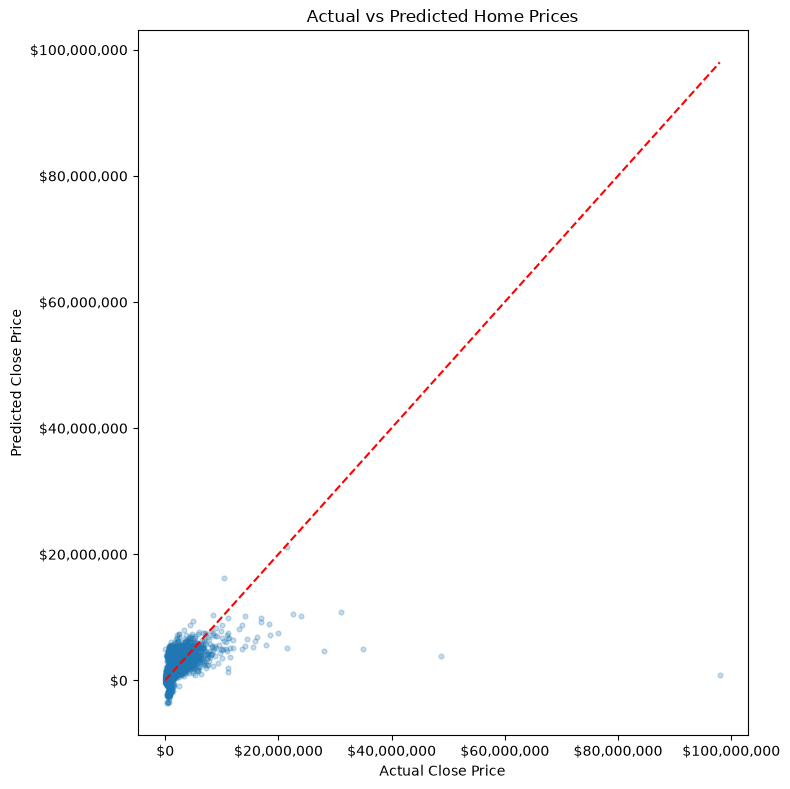

In [11]:
# Compare the model's predicted prices against the actual sale prices.
plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    predictions,
    alpha=0.25,
    s=12
)

plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("Actual vs Predicted Home Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.gca().xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
plt.tight_layout()
plt.show()

The baseline Linear Regression model is deterministic, so repeated runs using the same training data will produce identical results.

## Baseline Results

The Linear Regression model provides a starting point for evaluating future machine learning models.

The model explained approximately **24.8%** of the variation in home sale prices (**R² = 0.2484**). While this represents an improvement over earlier baseline results, a large portion of the variation in home sale prices remains unexplained, indicating that there is still considerable room for improvement.

The percentage-based error metrics (**MAPE = 65.03%** and **MdAPE = 33.41%**) also improved, suggesting that the revised preprocessing pipeline produced more accurate predictions. However, the baseline Linear Regression model still struggles to capture the complex, nonlinear relationships that influence California home prices.

These results establish an updated benchmark that future models will be compared against. More advanced machine learning algorithms, additional feature engineering, and hyperparameter tuning are expected to further improve predictive performance.

## Model Comparison

| Model             |      MAE |       RMSE |     R² |   MAPE |  MdAPE |
| ----------------- | -------: | ---------: | -----: | -----: | -----: |
| Linear Regression | $599,678 | $1,454,754 | 0.2484 | 65.03% | 33.41% |